# Задача: выявить корреляцию (или ее отсутствие) между размером словаря токенизатора и качеством модели (выраженном в f1) для задачи сентимент-анализа.
Предлагаемый план работ:
1. Ознакомиться с документацией и реализовать LightningDataModule (https://lightning.ai/docs/pytorch/stable/data/datamodule.html)
 - Загрузить датасет
 - Провести предобработку
 - Выбрать токенизатор (BPE, WordPiece, Unigram)
 - Реализовать collate_fn функцию токенизации для даталодера - encode
 - Добавить даталодеры
2. Ознакомиться с документацией и реализовать LightningModule (https://lightning.ai/docs/pytorch/LTS/common/lightning_module.html)
 - Выбрать и реализовать подходящую архитектуру модели для сентимент-анализа текста
 - Написать прямой проход модели
 - Написать training_step, validation_step, test_step
3. Провести цикл обучений модели
 - Ознакомиться с документацией и выбрать оптимальные настройки для Trainer (https://lightning.ai/docs/pytorch/stable//common/trainer.html)
 - Зафиксировать все гиперпараметры и провести обучение-валидацию-тестирование для 5 значений размера словаря (выбранных на ваше усмотрение)
 - Полученные результаты представить в виде гистограммы или любой другой визуализации

## Импорты

In [1]:
!pip install lightning
!pip install datasets
!pip install tokenizers
!pip install torchmetrics
!pip install pandas
!pip install matplotlib
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 18.7 MB/s eta 0:00:00


In [2]:
import torch
import datasets
import lightning.pytorch as pl
import tokenizers
from typing import *
import torchmetrics

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import datasets
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

import tokenizers
from tokenizers import Tokenizer
from tokenizers.models import BPE, Unigram, WordLevel
from tokenizers.trainers import BpeTrainer, UnigramTrainer, WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace

import torchmetrics
from torchmetrics import F1Score, Accuracy

from typing import Dict, List, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

## Загрузка

In [5]:
from google.colab import files

uploaded_neg = files.upload()
uploaded_pos = files.upload()

Saving negative.csv to negative (1).csv


Saving positive.csv to positive (1).csv


## Data

In [16]:
class MyDataModule(pl.LightningDataModule):
    def __init__(
        self,
        negative_file: str,
        positive_file: str,
        bs: int = 16,
        num_workers: int = 12,
        vocab_size: int = 5000,
        max_length: int = 256,
        test_size: float = 0.2,
        val_size: float = 0.1
    ):
        super().__init__()
        self.save_hyperparameters()

        self.bs = bs
        self.num_workers = num_workers
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.negative_file = negative_file
        self.positive_file = positive_file
        self.test_size = test_size
        self.val_size = val_size

        self.ds = None
        self.tokenizer = None
        self.label_dict = None

    def prepare_data(self):
        pass

    def clean_text(self, text):
        text = str(text)
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'[^\w\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def setup(self, stage=None):
        negative_df = pd.read_csv(
            self.negative_file,
            delimiter=";",
            header=None,
            names=["id", "tdate", "tname", "ttext", "ttype", "trep", "trtv", "tfav", "tstcount", "tfol", "tfrien", "listcount"],
            nrows=10000
        )

        positive_df = pd.read_csv(
            self.positive_file,
            delimiter=";",
            header=None,
            names=["id", "tdate", "tname", "ttext", "ttype", "trep", "trtv", "tfav", "tstcount", "tfol", "tfrien", "listcount"],
            nrows=10000
        )

        # Объединяем данные
        sentiment = pd.concat([negative_df, positive_df])[['ttext', 'ttype']]

        # Очищаем текст
        sentiment['ttext'] = sentiment['ttext'].apply(self.clean_text)

        # Удаляем пустые строки
        sentiment = sentiment[sentiment['ttext'].str.len() > 0]

        # Нормализуем метки: -1 -> 0, 1 -> 1
        sentiment.loc[sentiment.ttype < 0, 'ttype'] = 0

        # Создаем словарь меток
        self.label_dict = {0: 0, 1: 1}

        print(f"После очистки осталось записей: {len(sentiment)}")
        print(f"Распределение меток: {sentiment['ttype'].value_counts().to_dict()}")

        # Разделяем данные
        X = sentiment['ttext'].tolist()
        y = sentiment['ttype'].tolist()

        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y,
            test_size=self.test_size + self.val_size,
            random_state=42,
            stratify=y
        )

        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp,
            test_size=0.5,
            random_state=42,
            stratify=y_temp
        )

        print(f"Размеры выборок: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")

        # Создаем DatasetDict
        train_ds = Dataset.from_dict({"text": X_train, "label": y_train})
        val_ds = Dataset.from_dict({"text": X_val, "label": y_val})
        test_ds = Dataset.from_dict({"text": X_test, "label": y_test})

        self.ds = datasets.DatasetDict({
            "train": train_ds,
            "val": val_ds,
            "test": test_ds
        })

        # токенизатор (BPE)
        tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
        trainer = BpeTrainer(
            vocab_size=self.vocab_size,
            special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"]
        )


        tokenizer.train_from_iterator(self.ds['train']['text'], trainer=trainer)


        tokenizer.enable_truncation(self.max_length)
        tokenizer.enable_padding(pad_token="[PAD]", direction="left")
        self.tokenizer = tokenizer

    def train_dataloader(self):
        return DataLoader(
            self.ds["train"],
            batch_size=self.bs,
            shuffle=True,
            collate_fn=self.encode,
            num_workers=self.num_workers
        )

    def val_dataloader(self):
        return DataLoader(
            self.ds["val"],
            batch_size=self.bs,
            shuffle=False,
            collate_fn=self.encode,
            num_workers=self.num_workers
        )

    def test_dataloader(self):
        return DataLoader(
            self.ds["test"],
            batch_size=self.bs,
            shuffle=False,
            collate_fn=self.encode,
            num_workers=self.num_workers
        )

    def encode(self, batch):
        input_ids = self.tokenizer.encode_batch([x["text"] for x in batch])
        input_ids = torch.tensor([x.ids for x in input_ids])
        label = torch.tensor([x["label"] for x in batch])
        return {"input_ids": input_ids, "label": label}

## Model

In [18]:
class RNNModel(pl.LightningModule):
    def __init__(self, vocab_size, embd_size, hidden_size, output_size, dropout=0.3, num_layers=2):
        super(RNNModel, self).__init__()
        self.save_hyperparameters()

        self.embedding = torch.nn.Embedding(vocab_size, embd_size, padding_idx=0)

        self.rnn = torch.nn.RNN(
            embd_size,
            hidden_size,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,  # dropout работает только если num_layers > 1
            num_layers=num_layers
        )

        self.dropout = torch.nn.Dropout(dropout)
        self.fc = torch.nn.Linear(hidden_size, output_size)
        self.loss = torch.nn.CrossEntropyLoss()

        # Метрики
        self.train_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size)
        self.val_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size)
        self.test_f1 = torchmetrics.F1Score(task="multiclass", num_classes=output_size)

        # Добавляем accuracy для наглядности
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=output_size)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=output_size)
        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=output_size)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        x = self.embedding(x)  # (batch_size, seq_len, embd_size)
        x, _ = self.rnn(x)     # (batch_size, seq_len, hidden_size)
        x = self.dropout(x[:, -1, :])  # берем последний hidden state
        x = self.fc(x)          # (batch_size, output_size)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch["input_ids"], batch["label"]
        logits = self(x)
        loss = self.loss(logits, y)

        preds = torch.argmax(logits, dim=1)
        self.train_f1(preds, y)
        self.train_acc(preds, y)

        self.log('train_loss', loss, prog_bar=True, on_epoch=True)
        self.log('train_f1', self.train_f1, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_acc, on_step=False, on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch["input_ids"], batch["label"]
        logits = self(x)
        loss = self.loss(logits, y)

        preds = torch.argmax(logits, dim=1)
        self.val_f1(preds, y)
        self.val_acc(preds, y)

        self.log('val_loss', loss, prog_bar=True, on_epoch=True)
        self.log('val_f1', self.val_f1, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.val_acc, on_step=False, on_epoch=True, prog_bar=True)

        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch["input_ids"], batch["label"]
        logits = self(x)
        loss = self.loss(logits, y)

        preds = torch.argmax(logits, dim=1)
        self.test_f1(preds, y)
        self.test_acc(preds, y)

        self.log('test_loss', loss, on_epoch=True)
        self.log('test_f1', self.test_f1, on_step=False, on_epoch=True)
        self.log('test_acc', self.test_acc, on_step=False, on_epoch=True)

        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.0005, weight_decay=1e-5)
        return optimizer

## Trainer

In [21]:
MAX_LENGTH = 256
EMBD_SIZE = 128
HIDDEN_SIZE = 128
BATCH_SIZE = 16
MAX_EPOCHS = 5

VOCAB_SIZES = [1000, 3000, 5000, 10000, 20000]

all_results = []

for vocab_size in VOCAB_SIZES:

    print(f"Эксперимент {vocab_size}")

    # Создаем DataModule
    dm = MyDataModule(
        negative_file='negative.csv',
        positive_file='positive.csv',
        bs=BATCH_SIZE,
        vocab_size=vocab_size,
        max_length=MAX_LENGTH
    )

    dm.setup()

    real_vocab_size = dm.tokenizer.get_vocab_size()
    print(f"Реальный размер словаря: {real_vocab_size}")

    # Создаем модель
    model = RNNModel(
        vocab_size=real_vocab_size,
        embd_size=EMBD_SIZE,
        hidden_size=HIDDEN_SIZE,
        output_size=len(dm.label_dict),
        dropout=0.3,
        num_layers=2
    )

    # Early stopping
    early_stop = EarlyStopping(
        monitor="val_f1",
        mode="max",
        patience=2,
        verbose=True
    )

    # Trainer
    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        callbacks=[early_stop],
        accelerator="auto",
        devices=1,
        enable_progress_bar=True,
        log_every_n_steps=10
    )

    # Обучение
    trainer.fit(model, dm)

    # Тестирование
    test_result = trainer.test(model, dm)[0]

    all_results.append({
        "vocab_size": vocab_size,
        "real_vocab_size": real_vocab_size,
        "test_f1": test_result["test_f1"],
        "test_acc": test_result["test_acc"],
        "test_loss": test_result["test_loss"]
    })

    print(f"\nРезультаты для vocab_size = {vocab_size}:")
    print(f"  test_f1: {test_result['test_f1']:.4f}")
    print(f"  test_acc: {test_result['test_acc']:.4f}")
    print(f"  test_loss: {test_result['test_loss']:.4f}")


print("ТАБЛИЦА РЕЗУЛЬТАТОВ")
print(f"{'Размер словаря':<15} {'F1 Score':<10} {'Accuracy':<10} {'Loss':<10}")
for r in all_results:
    print(f"{r['vocab_size']:<15} {r['test_f1']:<10.4f} {r['test_acc']:<10.4f} {r['test_loss']:<10.4f}")

Эксперимент 1000
После очистки осталось записей: 20000
Распределение меток: {0: 10000, 1: 10000}
Размеры выборок: train=13999, val=3000, test=3001


INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

Фактический размер словаря: 1000
Реальный размер словаря: 1000
После очистки осталось записей: 20000
Распределение меток: {0: 10000, 1: 10000}
Размеры выборок: train=13999, val=3000, test=3001
Фактический размер словаря: 1000


┏━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ embedding │ Embedding          │  128 K │ train │     0 │
│ 1  │ rnn       │ RNN                │ 66.0 K │ train │     0 │
│ 2  │ dropout   │ Dropout            │      0 │ train │     0 │
│ 3  │ fc        │ Linear             │    258 │ train │     0 │
│ 4  │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 5  │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 6  │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
│ 7  │ test_f1   │ MulticlassF1Score  │      0 │ train │     0 │
│ 8  │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 9  │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 10 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
└────┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 194 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 194 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO: Metric val_f1 improved. New best score: 0.579
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved. New best score: 0.579
INFO: Metric val_f1 improved by 0.036 >= min_delta = 0.0. New best score: 0.614
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.036 >= min_delta = 0.0. New best score: 0.614
INFO: Metric val_f1 improved by 0.010 >= min_delta = 0.0. New best score: 0.624
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.010 >= min_delta = 0.0. New best score: 0.624
INFO: Metric val_f1 improved by 0.008 >= min_delta = 0.0. New best score: 0.633
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.008 >= min_delta = 0.0. New best score: 0.633
INFO: Metric val_f1 improved by 0.004 >= min_delta = 0.0. New best score: 0.636
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved by 0.004 >= min_delta = 0.0. New best score: 0.636
INFO: `Trainer.fit` stopped: `max_epochs=5` re

После очистки осталось записей: 20000
Распределение меток: {0: 10000, 1: 10000}
Размеры выборок: train=13999, val=3000, test=3001
Фактический размер словаря: 20000


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.6431189775466919     │
│          test_f1          │    0.6431189775466919     │
│         test_loss         │    0.7433162927627563     │
└───────────────────────────┴───────────────────────────┘


Результаты для vocab_size = 20000:
  test_f1: 0.6431
  test_acc: 0.6431
  test_loss: 0.7433
ТАБЛИЦА РЕЗУЛЬТАТОВ
Размер словаря  F1 Score   Accuracy   Loss      
1000            0.6208     0.6208     0.6507    
3000            0.6528     0.6528     0.6543    
5000            0.6658     0.6658     0.6580    
10000           0.6195     0.6195     0.7644    
20000           0.6431     0.6431     0.7433    


## Визуализация

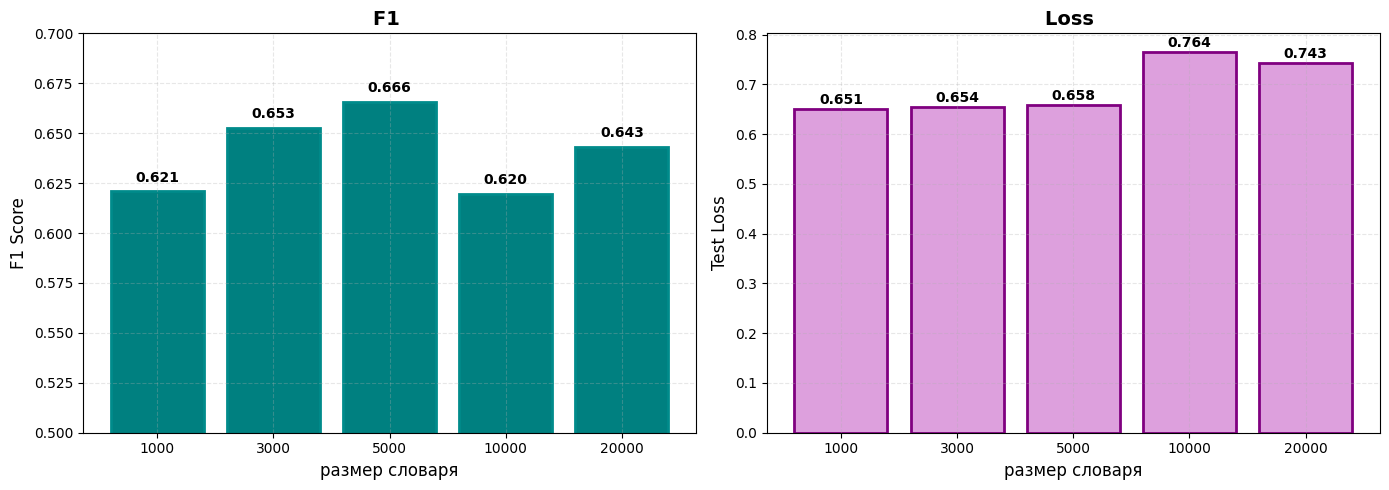

In [35]:
import matplotlib.pyplot as plt

vocab_sizes = [1000, 3000, 5000, 10000, 20000]
f1_scores = [0.6208, 0.6528, 0.6658, 0.6195, 0.6431]
losses = [0.6507, 0.6543, 0.6580, 0.7644, 0.7433]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(range(len(vocab_sizes)), f1_scores, color='teal', edgecolor='darkcyan', linewidth=2)
ax1.set_xlabel('размер словаря', fontsize=12)
ax1.set_ylabel('F1 Score', fontsize=12)
ax1.set_title('F1 ', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(vocab_sizes)))
ax1.set_xticklabels([str(v) for v in vocab_sizes])
ax1.set_ylim([0.5, 0.7])
ax1.grid(True, alpha=0.3, linestyle='--')

for bar, f1 in zip(bars1, f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{f1:.3f}', ha='center', fontsize=10, fontweight='bold')

bars2 = ax2.bar(range(len(vocab_sizes)), losses, color='plum', edgecolor='purple', linewidth=2)
ax2.set_xlabel('размер словаря', fontsize=12)
ax2.set_ylabel('Test Loss', fontsize=12)
ax2.set_title('Loss ', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(vocab_sizes)))
ax2.set_xticklabels([str(v) for v in vocab_sizes])
ax2.grid(True, alpha=0.3, linestyle='--')

for bar, loss in zip(bars2, losses):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{loss:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Результаты и выводы

Наибольшее значение F1 (0.666) достигнуто при размере словаря 5000 токенов.

При увеличении словаря с 1000 до 5000 наблюдается рост качества модели с 0.6208 до 0.6658. Дальнейшее увеличение до 10000 приводит к падению F1 до 0.6195, а при 20000 показатель восстанавливается до 0.6431, но не превышает значение, достигнутое при 5000. Значение loss при этом растет с 0.6507 до 0.7644 и 0.7433 соответственно, что свидетельствует о затруднениях модели при обобщении данных.

Таким образом, корреляция между размером словаря и качеством модели существует, но имеет нелинейный характер. Оптимальным для данного датасета является размер словаря 5000 токенов, обеспечивающий баланс между полнотой словарного запаса и способностью модели к обобщению. Слишком маленький словарь (1000) приводит к потере семантической информации, а слишком большой (10000 и более) — к появлению редких шумовых токенов, увеличивающих риск переобучения и ухудшающих качество классификации.

